In [1]:
%pip install torch torchvision --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys, cv2 as cv, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

import torch
import torch.nn as nn
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor, TwoMLPHead
from torchvision.models.detection.roi_heads import RoIHeads
from torchvision.ops import MultiScaleRoIAlign
from torch.utils.data import Dataset, DataLoader

print(f"torch {torch.__version__}  |  torchvision {torchvision.__version__}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")

SRC_DIR = Path("data/raw/easy")
CLASSES  = ["__background__", "treble", "slip_stitch", "chain", "double"]
CLS2IDX  = {c: i for i, c in enumerate(CLASSES)}
COLORS   = {"treble": "limegreen", "slip_stitch": "orangered",
            "chain": "dodgerblue", "double": "violet"}

torch 2.11.0  |  torchvision 0.26.0
device: cpu


In [3]:
# ── Preprocessing pipeline (full image — no triangle crop) ───────────────────
# For detection we use the WHOLE image so the model learns spatial context.

def get_contours(img_path, min_area=30, max_area=50000):
    """Run the OpenCV pipeline and return (gray_image, list_of_contours)."""
    img  = cv.imread(str(img_path))
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    _, thresh  = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    thresh_inv = cv.bitwise_not(thresh)
    kernel     = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
    closed     = cv.morphologyEx(thresh_inv, cv.MORPH_CLOSE, kernel)

    contours, _ = cv.findContours(closed, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    contours    = [c for c in contours if min_area < cv.contourArea(c) < max_area]
    contours    = _remove_contained(contours)
    return gray, contours


def _remove_contained(contours):
    boxes   = [cv.boundingRect(c) for c in contours]
    to_drop = set()
    for i, (xi, yi, wi, hi) in enumerate(boxes):
        for j, (xj, yj, wj, hj) in enumerate(boxes):
            if i != j and xi <= xj and yi <= yj and xi+wi >= xj+wj and yi+hi >= yj+hj:
                to_drop.add(i); break
    return [c for i, c in enumerate(contours) if i not in to_drop]


# Quick sanity-check: count contours per image
print(f"{'Image':<12} {'Contours':>10}")
print("-" * 25)
for p in sorted(SRC_DIR.glob("*.png")):
    _, cs = get_contours(p)
    print(f"{p.name:<12} {len(cs):>10}")


Image          Contours
-------------------------
12.png              131
13.png               75
14.png               73
2.png                63
20.png              358
21.png              358
22.png              286
26.png              202
3.png                60


In [4]:
# ── Generate pseudo-annotations using the SVM classifier ─────────────────────
# The already-trained SVM (baseline_ml.ipynb) labels every contour bbox.
# These pseudo-labels are the training signal for Cascade R-CNN.
# Replace with hand-annotated data once available for better accuracy.

sys.path.insert(0, ".")
from classifier import SymbolClassifier

clf = SymbolClassifier.load("model.joblib")
print(f"Classifier loaded.  Classes: {list(clf.label_encoder.classes_)}")

PADDING = 4

def build_annotations(img_path):
    """
    Returns a dict with:
        image_rgb : (H, W, 3) uint8
        boxes     : list of [x1, y1, x2, y2] pixel coords
        labels    : list of int class indices (matching CLASSES)
    """
    img      = cv.imread(str(img_path))
    gray     = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    _, contours = get_contours(img_path)

    boxes, labels = [], []
    h_img, w_img  = gray.shape
    for c in contours:
        x, y, w, h = cv.boundingRect(c)
        x1 = max(x - PADDING, 0);         y1 = max(y - PADDING, 0)
        x2 = min(x + w + PADDING, w_img); y2 = min(y + h + PADDING, h_img)
        crop  = gray[y1:y2, x1:x2]
        label = clf.predict(crop)
        if label not in CLS2IDX:
            continue
        boxes.append([x, y, x + w, y + h])
        labels.append(CLS2IDX[label])

    return {
        "image_rgb": cv.cvtColor(img, cv.COLOR_BGR2RGB),
        "boxes":     boxes,
        "labels":    labels,
    }

all_annotations = {}
for p in sorted(SRC_DIR.glob("*.png")):
    ann = build_annotations(p)
    all_annotations[p] = ann
    counts = {c: ann["labels"].count(CLS2IDX[c]) for c in CLASSES[1:]}
    print(f"{p.name:<12}  boxes={len(ann['boxes'])}  {counts}")


Classifier loaded.  Classes: [np.str_('chain'), np.str_('double'), np.str_('noise'), np.str_('slip_stitch'), np.str_('treble')]
12.png        boxes=77  {'treble': 45, 'slip_stitch': 32, 'chain': 0, 'double': 0}
13.png        boxes=29  {'treble': 18, 'slip_stitch': 11, 'chain': 0, 'double': 0}
14.png        boxes=46  {'treble': 36, 'slip_stitch': 10, 'chain': 0, 'double': 0}
2.png         boxes=41  {'treble': 32, 'slip_stitch': 9, 'chain': 0, 'double': 0}
20.png        boxes=164  {'treble': 46, 'slip_stitch': 118, 'chain': 0, 'double': 0}
21.png        boxes=176  {'treble': 44, 'slip_stitch': 103, 'chain': 25, 'double': 4}
22.png        boxes=134  {'treble': 85, 'slip_stitch': 49, 'chain': 0, 'double': 0}
26.png        boxes=143  {'treble': 16, 'slip_stitch': 127, 'chain': 0, 'double': 0}
3.png         boxes=18  {'treble': 3, 'slip_stitch': 12, 'chain': 0, 'double': 3}


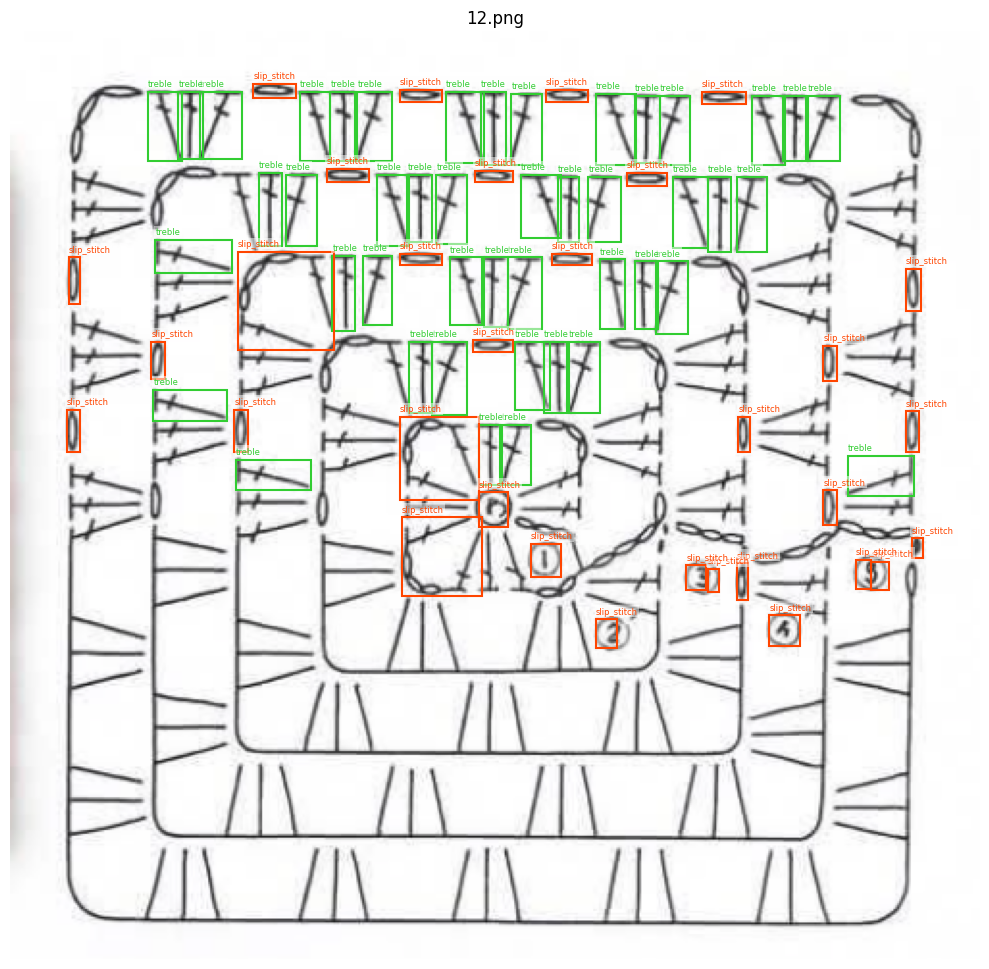

In [5]:
# ── Visualise annotations on one image ───────────────────────────────────────

def show_annotations(ann, title=""):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(ann["image_rgb"])
    for box, lbl_idx in zip(ann["boxes"], ann["labels"]):
        x1, y1, x2, y2 = box
        cls   = CLASSES[lbl_idx]
        color = COLORS.get(cls, "grey")
        rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=1.5, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 3, cls, color=color, fontsize=6,
                bbox=dict(facecolor="white", alpha=0.5, pad=1, edgecolor="none"))
    ax.set_title(title or f"{len(ann['boxes'])} annotations")
    ax.axis("off")
    plt.tight_layout(); plt.show()

first_path = sorted(SRC_DIR.glob("*.png"))[0]
show_annotations(all_annotations[first_path], title=first_path.name)


In [6]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────────

class CrochetDataset(Dataset):
    """
    Wraps annotation dicts into a torchvision-compatible dataset.
    Returns:
        image  : FloatTensor (3, H, W) in [0, 1]
        target : dict with 'boxes' (N,4), 'labels' (N,) tensors
    """
    def __init__(self, annotations: dict):
        self.items = list(annotations.items())

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, ann = self.items[idx]
        image  = torch.as_tensor(ann["image_rgb"], dtype=torch.float32).permute(2, 0, 1) / 255.0
        boxes  = torch.as_tensor(ann["boxes"],  dtype=torch.float32)
        labels = torch.as_tensor(ann["labels"], dtype=torch.int64)
        if boxes.ndim == 1:
            boxes = boxes.unsqueeze(0)
        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx])}
        return image, target


# Train / val split — last 2 images held out for validation
paths      = sorted(all_annotations.keys())
train_anns = {p: all_annotations[p] for p in paths[:-2]}
val_anns   = {p: all_annotations[p] for p in paths[-2:]}

train_ds = CrochetDataset(train_anns)
val_ds   = CrochetDataset(val_anns)
print(f"Train: {len(train_ds)} images  |  Val: {len(val_ds)} images")


def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, collate_fn=collate_fn)


Train: 7 images  |  Val: 2 images


In [7]:
# ── Cascade RoI Heads ─────────────────────────────────────────────────────────
# Three sequential detection heads, each with a stricter IoU threshold:
#   Stage 0  fg_iou=0.5   (standard Faster R-CNN threshold)
#   Stage 1  fg_iou=0.6   (tighter match required)
#   Stage 2  fg_iou=0.7   (highest quality predictions)
#
# Training  : all stages receive the same RPN proposals; each independently
#             assigns GT boxes using its own IoU threshold and computes losses.
# Inference : stage N's predicted boxes become stage N+1's proposals, so each
#             successive head refines the localisation of the previous one.

class CascadeRoIHeads(nn.Module):
    """3-stage Cascade RoI heads built on top of torchvision primitives."""

    IOU_THRESHOLDS = [0.5, 0.6, 0.7]

    def __init__(self, in_channels: int, num_classes: int,
                 representation_size: int = 1024):
        super().__init__()
        self.stages = nn.ModuleList()

        for iou_thresh in self.IOU_THRESHOLDS:
            box_roi_pool = MultiScaleRoIAlign(
                featmap_names=["0", "1", "2", "3"],
                output_size=7,
                sampling_ratio=2,
            )
            box_head      = TwoMLPHead(in_channels * 7 * 7, representation_size)
            box_predictor = FastRCNNPredictor(representation_size, num_classes)

            stage = RoIHeads(
                box_roi_pool=box_roi_pool,
                box_head=box_head,
                box_predictor=box_predictor,
                fg_iou_thresh=iou_thresh,
                bg_iou_thresh=iou_thresh - 0.1,
                batch_size_per_image=512,
                positive_fraction=0.25,
                bbox_reg_weights=None,
                score_thresh=0.05,      # keep low at each stage; final NMS cleans up
                nms_thresh=0.5,
                detections_per_img=100,
            )
            self.stages.append(stage)

    def forward(self, features, proposals, image_shapes, targets=None):
        """
        Returns (detections, losses) matching the signature FasterRCNN expects.
        """
        all_losses = {}

        if self.training:
            # ── Training ──────────────────────────────────────────────────────
            # All stages share the same RPN proposals but use different IoU
            # thresholds for GT assignment.  Losses are summed across stages.
            detections = None
            for i, stage in enumerate(self.stages):
                detections, stage_losses = stage(
                    features, proposals, image_shapes, targets
                )
                for k, v in stage_losses.items():
                    all_losses[f"cascade_s{i}_{k}"] = v
            return detections, all_losses

        else:
            # ── Inference ─────────────────────────────────────────────────────
            # Each stage refines the boxes produced by the previous stage.
            current_proposals = proposals
            for stage in self.stages:
                detections, _ = stage(
                    features, current_proposals, image_shapes, None
                )
                # Use predicted boxes as proposals for the next stage
                current_proposals = [d["boxes"] for d in detections]
            return detections, {}


In [8]:
# ── Build Cascade R-CNN model ─────────────────────────────────────────────────
# We reuse the pretrained ResNet-50 FPN backbone and RPN from Faster R-CNN,
# then swap in our CascadeRoIHeads.  The backbone is frozen to save memory
# and avoid overfitting on a small dataset.

def build_cascade_rcnn(num_classes: int) -> nn.Module:
    """
    Returns a FasterRCNN object whose roi_heads have been replaced with
    a 3-stage CascadeRoIHeads.  Backbone weights come from COCO pretraining.
    """
    # ── Pretrained base model ──────────────────────────────────────────────────
    base = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

    # FPN output channels (256 by default in torchvision's ResNet-50 FPN)
    in_channels = base.backbone.out_channels  # 256

    # ── Swap RoI heads ─────────────────────────────────────────────────────────
    base.roi_heads = CascadeRoIHeads(in_channels, num_classes)

    return base


model = build_cascade_rcnn(num_classes=len(CLASSES))
model.to(DEVICE)

# Freeze backbone — only train RPN + all 3 cascade stages
for name, param in model.named_parameters():
    if "backbone" in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
print(f"Cascade stages  : {len(model.roi_heads.stages)}")
print(f"IoU thresholds  : {CascadeRoIHeads.IOU_THRESHOLDS}")


Trainable params: 42,357,850 / 69,157,146  (61.2%)
Cascade stages  : 3
IoU thresholds  : [0.5, 0.6, 0.7]


In [9]:
# ── Training loop ─────────────────────────────────────────────────────────────

NUM_EPOCHS = 10
LR         = 0.005

optimizer    = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, momentum=0.9, weight_decay=1e-4,
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = {"train_loss": []}

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for images, targets in train_loader:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)   # returns {name: tensor, ...}
        loss      = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    lr_scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    history["train_loss"].append(avg_loss)

    # Print per-stage loss breakdown every 2 epochs
    if epoch % 2 == 0 or epoch == 1:
        stage_totals = {}
        for k, v in loss_dict.items():
            stage = k.split("_")[1]          # e.g. "s0", "s1", "s2"
            stage_totals[stage] = stage_totals.get(stage, 0) + v.item()
        breakdown = "  ".join(f"{s}={t:.3f}" for s, t in sorted(stage_totals.items()))
        print(f"Epoch {epoch:>2}/{NUM_EPOCHS}  loss={avg_loss:.4f}  [{breakdown}]")
    else:
        print(f"Epoch {epoch:>2}/{NUM_EPOCHS}  loss={avg_loss:.4f}")

print("\nTraining complete.")


Epoch  1/10  loss=8.5121  [objectness=1.133  rpn=0.409  s0=0.948  s1=0.784  s2=0.562]
Epoch  2/10  loss=4.6276  [objectness=1.044  rpn=0.418  s0=1.041  s1=0.544  s2=0.289]
Epoch  3/10  loss=3.7818
Epoch  4/10  loss=3.2257  [objectness=0.328  rpn=0.266  s0=1.240  s1=1.157  s2=0.852]
Epoch  5/10  loss=3.2497
Epoch  6/10  loss=3.0950  [objectness=0.605  rpn=0.385  s0=1.009  s1=0.779  s2=0.651]
Epoch  7/10  loss=2.9015
Epoch  8/10  loss=2.9168  [objectness=0.265  rpn=0.171  s0=1.045  s1=0.804  s2=0.471]
Epoch  9/10  loss=2.8121
Epoch 10/10  loss=2.8098  [objectness=0.401  rpn=0.291  s0=0.906  s1=0.795  s2=0.607]

Training complete.


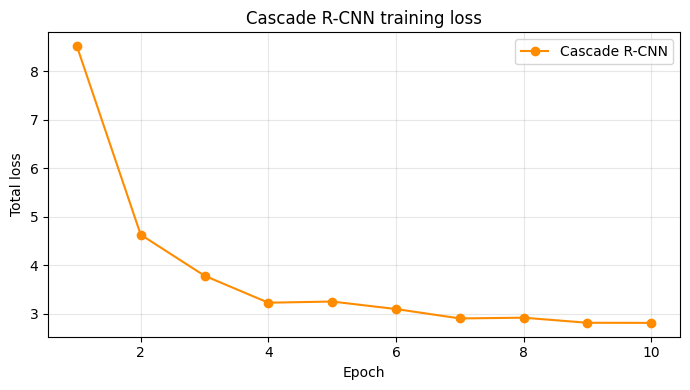

In [10]:
# ── Loss curve ────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(range(1, NUM_EPOCHS + 1), history["train_loss"],
         marker="o", color="darkorange", label="Cascade R-CNN")
plt.xlabel("Epoch"); plt.ylabel("Total loss")
plt.title("Cascade R-CNN training loss")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


Detections above threshold: 7


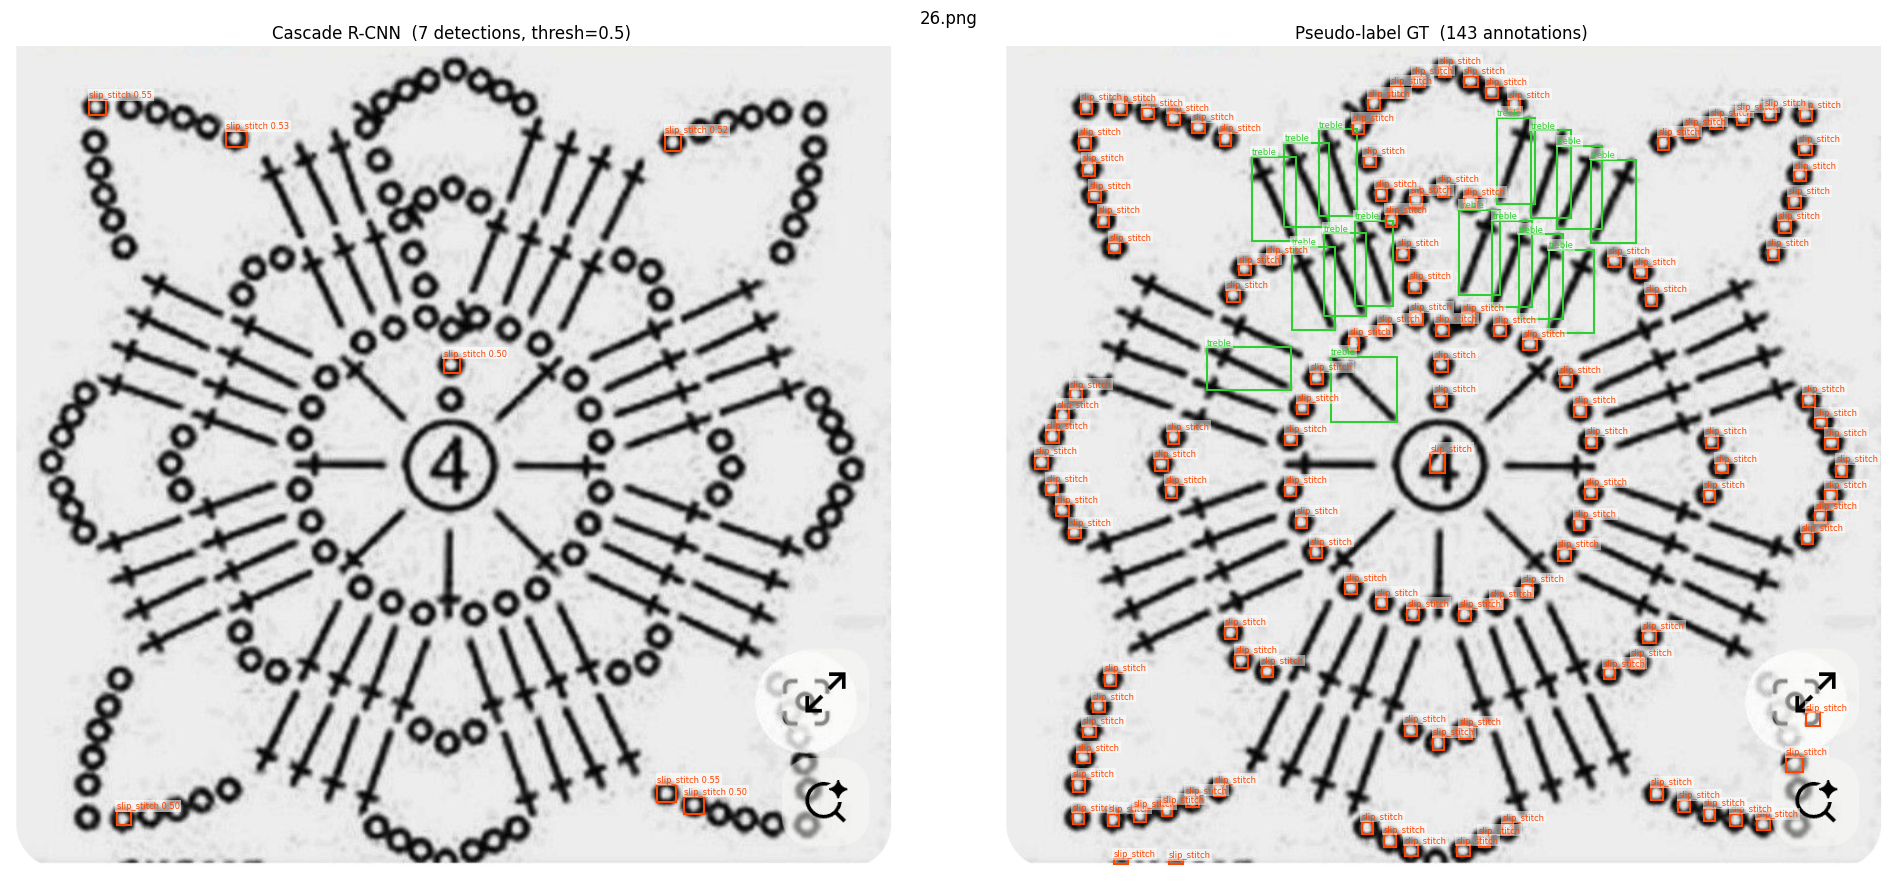

Detections above threshold: 8


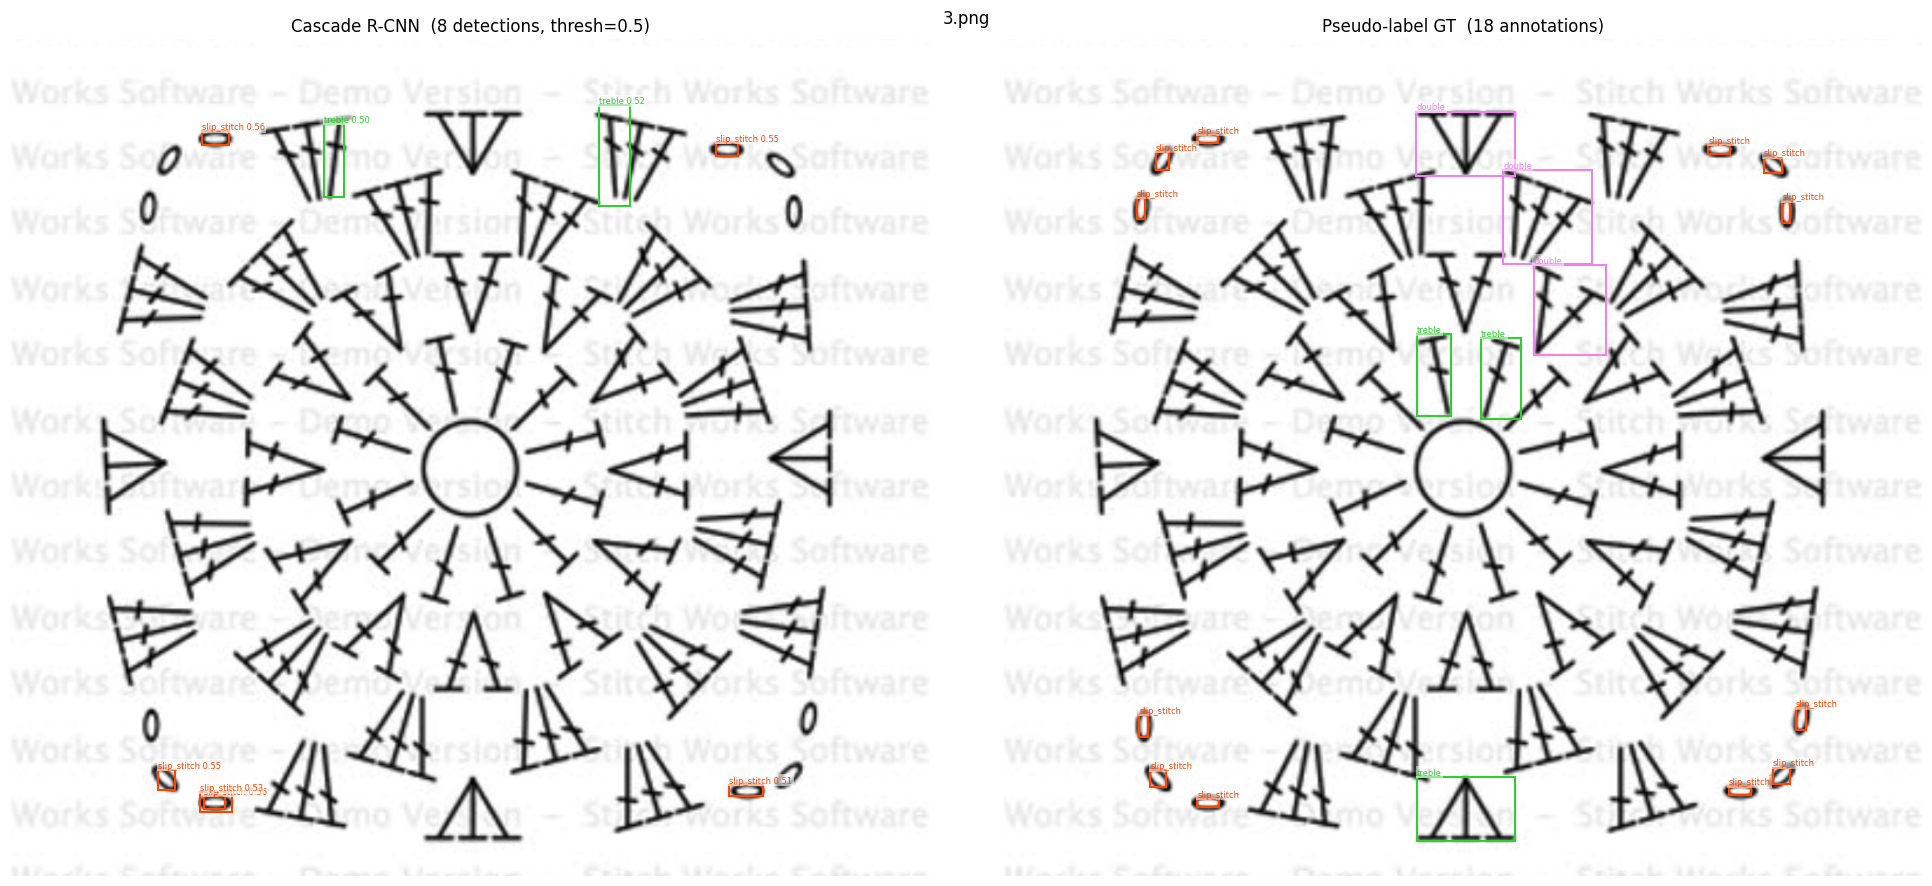

In [11]:
# ── Inference on validation images ───────────────────────────────────────────

SCORE_THRESHOLD = 0.5

def predict(model, img_tensor):
    """Run inference on a single (3, H, W) float tensor."""
    model.eval()
    with torch.no_grad():
        outputs = model([img_tensor.to(DEVICE)])
    return outputs[0]


def show_predictions(img_rgb, preds, gt_ann=None,
                     score_thresh=SCORE_THRESHOLD, title=""):
    ncols = 2 if gt_ann is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(10 * ncols, 9))
    if ncols == 1:
        axes = [axes]

    # Left: Cascade R-CNN predictions
    ax = axes[0]
    ax.imshow(img_rgb)
    boxes  = preds["boxes"].cpu()
    labels = preds["labels"].cpu()
    scores = preds["scores"].cpu()
    kept   = 0
    for box, lbl, score in zip(boxes, labels, scores):
        if score < score_thresh:
            continue
        kept += 1
        x1, y1, x2, y2 = box.tolist()
        cls   = CLASSES[lbl.item()]
        color = COLORS.get(cls, "grey")
        rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=1.5, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 3, f"{cls} {score:.2f}", color=color, fontsize=6,
                bbox=dict(facecolor="white", alpha=0.6, pad=1, edgecolor="none"))
    ax.set_title(f"Cascade R-CNN  ({kept} detections, thresh={score_thresh})")
    ax.axis("off")

    # Right: pseudo-label ground truth (if provided)
    if gt_ann is not None:
        ax2 = axes[1]
        ax2.imshow(img_rgb)
        for box, lbl_idx in zip(gt_ann["boxes"], gt_ann["labels"]):
            x1, y1, x2, y2 = box
            cls   = CLASSES[lbl_idx]
            color = COLORS.get(cls, "grey")
            rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=1.5, edgecolor=color, facecolor="none")
            ax2.add_patch(rect)
            ax2.text(x1, y1 - 3, cls, color=color, fontsize=6,
                     bbox=dict(facecolor="white", alpha=0.5, pad=1, edgecolor="none"))
        ax2.set_title(f"Pseudo-label GT  ({len(gt_ann['boxes'])} annotations)")
        ax2.axis("off")

    plt.suptitle(title, fontsize=12)
    plt.tight_layout(); plt.show()


# Run inference on every validation image
for (img_tensor,), (target,) in val_loader:
    img_rgb = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    preds   = predict(model, img_tensor)
    kept    = (preds["scores"] >= SCORE_THRESHOLD).sum().item()
    print(f"Detections above threshold: {kept}")

    # Look up the GT annotations for this image
    val_path = list(val_anns.keys())[target["image_id"].item()]
    gt_ann   = val_anns[val_path]
    show_predictions(img_rgb, preds, gt_ann=gt_ann, title=val_path.name)


In [12]:
# ── Save model ────────────────────────────────────────────────────────────────
torch.save(model.state_dict(), "cascade_rcnn.pth")
print("Model saved to cascade_rcnn.pth")

# ── Reload example ────────────────────────────────────────────────────────────
# model = build_cascade_rcnn(num_classes=len(CLASSES))
# model.load_state_dict(torch.load("cascade_rcnn.pth", map_location=DEVICE))
# model.to(DEVICE)


Model saved to cascade_rcnn.pth
